In [ ]:
# Librairies
from fismi import sdxData as sdx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from fismi import utils

np.set_printoptions(suppress=True, precision=4)
plt.rcParams["figure.figsize"] = (9, 5)

# EA Data
Sources : 
- [Metadata](https://ec.europa.eu/eurostat/cache/metadata/en/prc_hicp_esms.htm#cost_burdenDisseminated) (European Commission)
- [SDW API examples](https://data.ecb.europa.eu/help/api/useful-tips) (European Central Bank)
- [Components and computation methodology](https://ec.europa.eu/eurostat/web/hicp/information-data#Coverage) (European Commission)

## Definition
We collect the HICP and its components on a monthly grid for the EA. The data is provided by the European Central Bank (SDW). The series are adjusted for hollidays and seasonality, available at a monthly frequency since 1997-01 and expressed in base 100 = 2025. 

The HICP index is broken down following the European Classification of Individual Consumption According to Purpose (ECOICOP) that you can find [here (ECOICOP 2)](https://showvoc.op.europa.eu/#/datasets/ESTAT_European_Classification_of_Individual_Consumption_according_to_Purpose_version_2__ECOICOP_2/unknown/data).

We also collect ECOICOP 2 item weights from the [Eurostat PRC_HICP_INW database](https://ec.europa.eu/eurostat/databrowser/view/prc_hicp_inw__custom_22798527/default/table). The weights sum to 1,000 and represent the share that the *representative EA household* spend into each of the HICP's items.

### Index sub-components
From the [European Commission website](https://showvoc.op.europa.eu/#/datasets/ESTAT_European_Classification_of_Individual_Consumption_according_to_Purpose_version_2__ECOICOP_2/unknown/downloads) (ShowVoc), we see that [ECOICOIP 1 levels](https://www.insee.fr/fr/information/2402696) display the following granularity (number of items) : 
- Level 0 : HICP Total - All Items (1)
- Level 1 : 12 divisions (exclude "13 - Personal Care, Social Protection and Miscellanous G&S")
- Level 2 : 47 groups
- Level 3 : 117 classes
- Level 4 : 303 sub-classes
- Level 5 : 410 postes

Regarding ECOICOIP 2, we have the following items per expense category level ([see INSEE website](https://www.insee.fr/fr/information/8675839)) : 
- Level 0 : HICP Total - All Items (1)
- Level 1 : 13 divisions
- Level 2 : 52 groups
- Level 3 : 146 classes
- Level 4 : 298 sub-classes
- Level 5 : 440 postes

The ECOICOP codes (and their sub-items) not used for HICP purposes are the following :
- 02.4 Narcotics
- 04.2 Imputed rentals for housing
- 12.2.1 Financial intermediation services indirectly measured
- 13.9.1 Prostitution
- 12.1.1.0 Life and accident insurance
- 12.1.2.0 Insurance connected with health

In [228]:
### ECB Website = ECOICOP 1 around 465 series 

## WS URL and dataset query
## Metadata : 
## HICP = Database
## M    = Frequency (monthly)
## U2   = EA changing composition
## Y    = Working days and seasonally adjusted series
## 4D0  = European Commission (Eurostat)
## 4F0  = ECB (SDW)
## INX  = Index

url = "https://data-api.ecb.europa.eu/service/data/HICP/M.U2.N..4D0.INX"
dfIdx, tempIdx = sdx.getEcbData(url, colName="KEY", params=None)



/Users/lea_gosselin/GitRepo/ismi-index/.venv/lib/python3.11/site-packages/urllib3/connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'data-api.ecb.europa.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/Users/lea_gosselin/GitRepo/ismi-index/fismi/sdxData.py:19: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  temp = pd.read_csv(io.StringIO(response.text))


In [229]:
### Alternative datasource

### Eurostat = ECOICOP 2 but 416 and starts later

## Metadata : 
## prc_hicp_midx = Database
## M             = Frequency (monthly)
## EA            = EA changing composition
## I15           = Base 2015 = 100

# url = "https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/prc_hicp_midx/M.I15..EA"
# dfIdx, tempIdx = sdx.getEcbData(url, colName="coicop", headers=None)
# tempIdx

### Items' weights

In [230]:
### ECB Website = ECOICOP 1 around 471 series 

## WS URL and dataset query
## Metadata : 
## HICP = Database
## M    = Frequency (monthly)
## U2   = EA changing composition
## Y    = Working days and seasonally adjusted series
## 4D0  = European Commission (Eurostat)
## 4F0  = ECB (SDW)
## INX  = Index

url = "https://data-api.ecb.europa.eu/service/data/HICP/A.U2.N...INW"
dfW, tempW = sdx.getEcbData(url, colName="KEY", params=None)

/Users/lea_gosselin/GitRepo/ismi-index/.venv/lib/python3.11/site-packages/urllib3/connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'data-api.ecb.europa.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


In [231]:
# Do we dispose of all indexes and series available ?
print(f"ECB provider, number of ICP items' weights {len(tempW['ICP_ITEM'].unique())}")
print(f"ECB provider, number of ICP indexes {len(tempIdx['ICP_ITEM'].unique())}")

ECB provider, number of ICP items' weights 471
ECB provider, number of ICP indexes 465


In [232]:
# Get ECOICOP sub-keys from the Index table
uniKeys = tempIdx.KEY.unique()
unEcoicop = [[i, i.split(".")[4]] for i in uniKeys]
temp = pd.DataFrame(unEcoicop, columns=["KEY", "ecoicop"])
tempIdx = pd.merge(tempIdx, temp, how="left", on="KEY")
tempIdx["ICP_ITEM"] = tempIdx["ecoicop"].values

# Dates management
tempIdx['TIME_PERIOD'] = pd.to_datetime(tempIdx['TIME_PERIOD'].astype(str), format='%Y-%m')

# Rename 
tempIdx = tempIdx.rename(columns={"OBS_VALUE":"INX"})

# Resize
dfIdx = tempIdx[["KEY", "TITLE", "ICP_ITEM", "TIME_PERIOD", "INX"]]


In [233]:
## Prepare the weights table for the merge
# Convert to the first month of each year : January-YY
tempW['TIME_PERIOD'] = pd.to_datetime(tempW['TIME_PERIOD'].astype(str) + "-01", format='%Y-%m')

# Rename
tempW = tempW.rename(columns={"OBS_VALUE":"WEIGHTS"})

# Resize
dfW = tempW[["ICP_ITEM", "TIME_PERIOD", "WEIGHTS"]]


### Merge and clean index / weight databases

In [234]:
# We merge both dataframes
dFinal = pd.merge(
    dfIdx, dfW,
    how="left",
    left_on=["TIME_PERIOD", "ICP_ITEM"],
    right_on=["TIME_PERIOD", "ICP_ITEM"]
)

dFinal

,KEY,TITLE,ICP_ITEM,TIME_PERIOD,INX,WEIGHTS
0,HICP.M.U2.N.000000.4D0.INX,HICP Inflation rate - Total - Index,000000,1990-01-01,NaN,NaN
1,HICP.M.U2.N.000000.4D0.INX,HICP Inflation rate - Total - Index,000000,1990-02-01,NaN,NaN
2,HICP.M.U2.N.000000.4D0.INX,HICP Inflation rate - Total - Index,000000,1990-03-01,NaN,NaN
3,HICP.M.U2.N.000000.4D0.INX,HICP Inflation rate - Total - Index,000000,1990-04-01,NaN,NaN
4,HICP.M.U2.N.000000.4D0.INX,HICP Inflation rate - Total - Index,000000,1990-05-01,NaN,NaN
...,...,...,...,...,...,...
112281,HICP.M.U2.N.XSEAS0.4D0.INX,HICP Inflation rate - Total excluding seasonal...,XSEAS0,2026-04-01,102.96,NaN
112282,HICP.M.U2.N.XSEAS0.4D0.INX,HICP Inflation rate - Total excluding seasonal...,XSEAS0,2026-05-01,103.08,NaN
112283,HICP.M.U2.N.XSEAS0.4D0.INX,HICP Inflation rate - Total excluding seasonal...,XSEAS0,2026-06-01,103.03,NaN
112284,HICP.M.U2.N.XSEAS0.4D0.INX,HICP Inflation rate - Total excluding seasonal...,XSEAS0,2026-07-01,103.31,NaN


In [235]:
# We isolate atypical ECOICOP codes
ecoicop = pd.Series(dFinal['ICP_ITEM'].unique())
atypicalCodes = ecoicop[~ecoicop.str.match(r'^\d{6}$')]

# We construct the different divisions, groups, classes, subclasses and position
h = pd.DataFrame({'ICP_ITEM': ecoicop})
h['div']   = h['ICP_ITEM'].str[:2] + '0000'
h['group']     = h['ICP_ITEM'].str[:3] + '000'
h['class']     = h['ICP_ITEM'].str[:4] + '00'
h['ssclass']   = h['ICP_ITEM'].str[:5] + '0'
h['pos']   = h['ICP_ITEM']

# Finally, the level of the item
h['Level'] = np.select(
    [h['ICP_ITEM'] == h['div'],
     h['ICP_ITEM'] == h['group'],
     h['ICP_ITEM'] == h['class'],
     h['ICP_ITEM'] == h['ssclass']],
    ['1', '2', '3', '4'],
    default='5' # Position
)

# Merge with the DB
dFinal = dFinal.merge(h, how="left", on="ICP_ITEM")

# Deal with Headline Inflation
dFinal.loc[dFinal.KEY == "HICP.M.U2.N.000000.4D0.INX", "Level"] = '0'   # Headline

# Deal with atypical codes
dFinal.loc[dFinal.ICP_ITEM.isin(atypicalCodes), "Level"] = "Other"
dFinal

,KEY,TITLE,ICP_ITEM,TIME_PERIOD,INX,WEIGHTS,div,group,class,ssclass,pos,Level
0,HICP.M.U2.N.000000.4D0.INX,HICP Inflation rate - Total - Index,000000,1990-01-01,NaN,NaN,000000,000000,000000,000000,000000,0
1,HICP.M.U2.N.000000.4D0.INX,HICP Inflation rate - Total - Index,000000,1990-02-01,NaN,NaN,000000,000000,000000,000000,000000,0
2,HICP.M.U2.N.000000.4D0.INX,HICP Inflation rate - Total - Index,000000,1990-03-01,NaN,NaN,000000,000000,000000,000000,000000,0
3,HICP.M.U2.N.000000.4D0.INX,HICP Inflation rate - Total - Index,000000,1990-04-01,NaN,NaN,000000,000000,000000,000000,000000,0
4,HICP.M.U2.N.000000.4D0.INX,HICP Inflation rate - Total - Index,000000,1990-05-01,NaN,NaN,000000,000000,000000,000000,000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...
112281,HICP.M.U2.N.XSEAS0.4D0.INX,HICP Inflation rate - Total excluding seasonal...,XSEAS0,2026-04-01,102.96,NaN,XS0000,XSE000,XSEA00,XSEAS0,XSEAS0,Other
112282,HICP.M.U2.N.XSEAS0.4D0.INX,HICP Inflation rate - Total excluding seasonal...,XSEAS0,2026-05-01,103.08,NaN,XS0000,XSE000,XSEA00,XSEAS0,XSEAS0,Other
112283,HICP.M.U2.N.XSEAS0.4D0.INX,HICP Inflation rate - Total excluding seasonal...,XSEAS0,2026-06-01,103.03,NaN,XS0000,XSE000,XSEA00,XSEAS0,XSEAS0,Other
112284,HICP.M.U2.N.XSEAS0.4D0.INX,HICP Inflation rate - Total excluding seasonal...,XSEAS0,2026-07-01,103.31,NaN,XS0000,XSE000,XSEA00,XSEAS0,XSEAS0,Other


In [236]:
# Architecture ECOICOIP as made available by the ECB 
dFinal[["KEY", "TITLE", "ICP_ITEM", "div", "group", "class", "ssclass", "pos", "Level"]].drop_duplicates()

,KEY,TITLE,ICP_ITEM,div,group,class,ssclass,pos,Level
0,HICP.M.U2.N.000000.4D0.INX,HICP Inflation rate - Total - Index,000000,000000,000000,000000,000000,000000,0
440,HICP.M.U2.N.010000.4D0.INX,HICP Inflation rate - Food and non-alcoholic b...,010000,010000,010000,010000,010000,010000,1
808,HICP.M.U2.N.011000.4D0.INX,HICP Inflation rate - Food - Index,011000,010000,011000,011000,011000,011000,2
1176,HICP.M.U2.N.011100.4D0.INX,HICP Inflation rate - Cereals and cereal produ...,011100,010000,011000,011100,011100,011100,3
1544,HICP.M.U2.N.011110.4D0.INX,HICP Inflation rate - Cereals (ND) - Index,011110,010000,011000,011100,011110,011110,4
...,...,...,...,...,...,...,...,...,...
110446,HICP.M.U2.N.XEFUN0.4D0.INX,HICP Inflation rate - Total excluding energy a...,XEFUN0,XE0000,XEF000,XEFU00,XEFUN0,XEFUN0,Other
110814,HICP.M.U2.N.XESEAS.4D0.INX,HICP Inflation rate - Total excluding energy a...,XESEAS,XE0000,XES000,XESE00,XESEA0,XESEAS,Other
111182,HICP.M.U2.N.XFROOP.4D0.INX,HICP Inflation rate - Total excluding frequent...,XFROOP,XF0000,XFR000,XFRO00,XFROO0,XFROOP,Other
111550,HICP.M.U2.N.XFUELL.4D0.INX,HICP Inflation rate - Total excluding liquid f...,XFUELL,XF0000,XFU000,XFUE00,XFUEL0,XFUELL,Other


In [237]:
# Get official ECOICOP codes from EC's Sparql
official = sdx.getEcoicopCodes()

In [238]:
# Check EC versus ECB's match and identify the missing ones
codes_officiels = set(official['code_norm'])
codes_recons = set(h['ICP_ITEM'])

missingEcbDb = {c for c in (codes_officiels - codes_recons) if c[:1].isdigit()}
missingComDb   = codes_recons - codes_officiels

print(f"{len(missingEcbDb)} missing EC's codes in our DB :", sorted(missingEcbDb))

17 missing EC's codes in our DB : ['011210', '011227', '013000', '024000', '042000', '042100', '042200', '044120', '052200', '054040', '071400', '073290', '091220', '112090', '122100', '131120', '139010']


In [239]:
# List of missing ones
official[official["code_norm"].isin(missingEcbDb)].drop_duplicates(subset="code_norm")

,code,label,parent_code,code_norm
4,01.1.2.1,01.1.2.1 Live land animals (ND),01.1.2,011210
25,02.4.0.0,02.4.0.0 Narcotics (ND),02.4.0,024000
55,07.1.4.0,07.1.4.0 Animal-drawn vehicles (D),07.1.4,071400
95,09.1.2.2,"09.1.2.2 Aeroplanes, microlight aircraft, glid...",09.1.2,091220
200,01.3.0.0,01.3.0.0 Services for processing primary goods...,01.3.0,013000
225,04.2,04.2 Imputed rental payments for housing,04,042000
231,04.2.1,04.2.1 Imputed rental payments of owner-occupi...,04.2,042100
232,04.2.2,04.2.2 Other imputed rentals (S),04.2,042200
250,04.4.1.2,04.4.1.2 Water supply delivered through other ...,04.4.1,044120
272,05.2.2,"05.2.2 Repair, hire and sewing services of hou...",05.2,052200


In a nutshell, the ECOICOP codes that are missing from our ECB's database are the following : 
- 02.4 Narcotics, 04.2 Imputed rentals for housing (incl. sub-classes 04.2.1 and 04.2.2), 12.2.1 Financial Intermediation services indirectly measured, 13.9.0.1 Prostitution and **those are not** accounted for in the calculus of the HICP Total
- 01.1.2.1 Live land animals, 01.1.2.2.7 Meat of camels and camelids, fresh, chilled or frozen, 01.3.0 Services for processing primary goods for food and non-alcoholic beverages
- 04.4.1.2 Water supply delivered through other systems 
- 05.2.2 Repair, hire and sewing services of household textiles
- 05.4.0.4 Repair and hire of glassware, tableware and household utensils
- 07.1.4 Animal-drawn vehicles
- 07.3.2.9 Other passenger transport by road
- 09.1.2.2 Aeroplanes, microlight aircraft, gliders, hang gliders and hot-air balloons
- 11.2.0.9 Other accommodation services
- 13.1.1.2 Repair of electric appliances for personal care


Levels 4 and 5 are less reliable (missing items). 

So in conclusion, **Levels 1 and 2 are reliable**. 

**Level 3 is re-weighted** such as we do not account for :
- 05.2.2 Repair, hire and sewing services of household textiles
- 07.1.4 Animal-drawn vehicles
- 01.3.0 Services for processing primary goods for food and non-alcoholic beverages

**Level 4 is re-weighted**, we do not account for : 
- 01.1.2.1 Live land animals
- 04.4.1.2 Water supply delivered through other systems 
- 05.4.0.4 Repair and hire of glassware, tableware and household utensils
- 07.3.2.9 Other passenger transport by road
- 09.1.2.2 Aeroplanes, microlight aircraft, gliders, hang gliders and hot-air balloons
- 11.2.0.9 Other accommodation services
- 13.1.1.2 Repair of electric appliances for personal care

**Level 5 is re-weighted**, we do not account for : 
- 01.1.2.2.7 Meat of camels and camelids, fresh, chilled or frozen


In [240]:
# Data availability
resume = dFinal.groupby(["Level", "ICP_ITEM", "TITLE"]).agg(
    date_min=("TIME_PERIOD", "min"),
    date_max=("TIME_PERIOD", "max"),
    nb_obs_inx=("INX", "count"),
    nb_obs_weight=("WEIGHTS", "count"),
    mean_weight=("WEIGHTS", "mean")
).reset_index()
resume

,Level,ICP_ITEM,TITLE,date_min,date_max,nb_obs_inx,nb_obs_weight,mean_weight
0,0,000000,HICP Inflation rate - Total - Index,1990-01-01,2026-08-01,368,31,1000.000000
1,1,010000,HICP Inflation rate - Food and non-alcoholic b...,1996-01-01,2026-08-01,368,31,159.925484
2,1,020000,"HICP Inflation rate - Alcoholic beverages, tob...",1996-01-01,2026-08-01,368,31,39.971935
3,1,030000,HICP Inflation rate - Clothing and footwear - ...,1996-01-01,2026-08-01,368,31,66.817419
4,1,040000,"HICP Inflation rate - Housing, water, electric...",1996-01-01,2026-08-01,368,31,159.815484
...,...,...,...,...,...,...,...,...
459,Other,XEFUN0,HICP Inflation rate - Total excluding energy a...,1996-01-01,2026-08-01,309,26,835.924231
460,Other,XESEAS,HICP Inflation rate - Total excluding energy a...,1996-01-01,2026-08-01,368,26,869.111154
461,Other,XFROOP,HICP Inflation rate - Total excluding frequent...,1996-01-01,2026-08-01,321,26,562.303077
462,Other,XFUELL,HICP Inflation rate - Total excluding liquid f...,1996-01-01,2026-08-01,368,26,951.028462


In [241]:
# % de NaN par niveau...
# We denote N the expected number of items per level of disaggregation (we exclude the ECOICOP codes that do not enter in the HICP calculation) 
# We denote T the number of observation of the longest series available queried from the ECB website

expN = [13, 50, 144, 296, 440]
levels = ["1", "2", "3", "4", "5"]

for i in range(len(levels)):

    # Niveau N°
    lvl = levels[i]
    N = expN[i]
    print(f"Level : {lvl}")
        
    # Resize DataFrame on Niveau
    dfLvl = dFinal[dFinal.Level==lvl].pivot(index="TIME_PERIOD",values="INX",columns="ICP_ITEM")
    
    # Number of observations per item (longest series)
    T = dfLvl.shape[0]
    ActualNbCols = dfLvl.shape[1]
    
    # Expected number of observations T*N
    nbExpected = N*T

    print(f"Expected Nb. Items (N) = {N}")
    print(f"Expected Nb. Obs. (T) = {T}")
    print(f"Expected Total = {nbExpected}")
    
    # Missing values
    NbMissingVals = dfLvl.isna().sum().sum()
    globMiss = (nbExpected - (T*ActualNbCols - NbMissingVals)) / nbExpected

    print(f"Global missing-data ratio for Level {lvl} : {globMiss*100:.0f}%")
    print("")

Level : 1
Expected Nb. Items (N) = 13
Expected Nb. Obs. (T) = 368
Expected Total = 4784
Global missing-data ratio for Level 1 : 0%

Level : 2
Expected Nb. Items (N) = 50
Expected Nb. Obs. (T) = 368
Expected Total = 18400
Global missing-data ratio for Level 2 : 9%

Level : 3
Expected Nb. Items (N) = 144
Expected Nb. Obs. (T) = 368
Expected Total = 52992
Global missing-data ratio for Level 3 : 18%

Level : 4
Expected Nb. Items (N) = 296
Expected Nb. Obs. (T) = 117
Expected Total = 34632
Global missing-data ratio for Level 4 : 28%

Level : 5
Expected Nb. Items (N) = 440
Expected Nb. Obs. (T) = 117
Expected Total = 51480
Global missing-data ratio for Level 5 : 98%



From the table above, we observe that : 
- **Level 1 :** all 13 items are available from 01-01-19996 to 2026-08-01 at a monthly frequency (368 observations), also with their weights.
- **Level 2 :** almost all of the 49 ECB's provided items and weights are available between 01-01-1996 and 2026-08-01 at a monthly frequency. One of them ("022000 - Alcohol Production Services") as an average weight of 0 (9 observations) ; hence, we neglect it. For the other incomplete series (from 201 to 321 observations) we decide to fill the gaps with previous valus of the index. The average weights associated to these items span between 0.13 and 19.64 (per 1,000).
- **Level 3 :** we have 126 series, 29 of them are incomplete. For those series, the number of observations span from 201 to 345. One of them **has been made available only since Dec-2025** very recently ; "094700 - HICP Inflation rate - Games of chance" and weights for quite a lot (12). Except for the latter, we fill the missing data with previous observations. The latter will be included into the sub-component of the HICP Total as of 2025-12. 
- **Level 4 :** most of the 216 series provided by the ECB are available between 12-2016 and 08-2026 (117 observations). 2 of them ("133090 - Other social protection services" and "011370 - Livers, roes and other offal of fish and of other seafood in all forms") are mostly incomplete, and have an average weight of 0 ; we exclude them. For the other ones, we have between 93 and 109 observations available hence we decide to forward fill the missing values. 
- **Level 5 :** EU does not publish all Level 5 series (optional)

In [242]:
# Remove series were mainly NaN (and low weight)
cleanDf = dFinal[~dFinal["ICP_ITEM"].isin(["022000", "133090", "011370"])]

In [243]:
# Check the weights per child and parent categories
lvls = [niv for niv in cleanDf.Level.unique() if niv not in ["Other", "0", "5"]]

for niv in lvls:
    print(f"Sum of Level {niv} weights - Must equal to 1,000")
    Weights = cleanDf[cleanDf.Level == niv].pivot(columns="ICP_ITEM", values="WEIGHTS", index="TIME_PERIOD")
    Weights.ffill(inplace=True)
    W = Weights.sum(axis=1)
    minW = np.round(W.min(), 2)
    maxW = np.round(W.max(), 2)
    meanW = np.round(W.mean(), 2)
    
    print(f"Minimum = {minW}, Mean = {meanW}, Maximum = {maxW}, Last = {W.iloc[-1]}")
    print("")

Sum of Level 1 weights - Must equal to 1,000
Minimum = 999.98, Mean = 1000.0, Maximum = 1000.01, Last = 1000.01

Sum of Level 2 weights - Must equal to 1,000
Minimum = 958.24, Mean = 994.17, Maximum = 1000.05, Last = 1000.03

Sum of Level 3 weights - Must equal to 1,000
Minimum = 784.24, Mean = 863.26, Maximum = 914.6, Last = 898.9799999999999

Sum of Level 4 weights - Must equal to 1,000
Minimum = 0.0, Mean = 703.17, Maximum = 716.76, Last = 715.53



### Re-construction of HICP index from its sub-items

The HICP is computed as a **chain-linked Laspeyres-type** index, from which we can deduce the following aggregation of indices : 
1. The series (indices) need to be unchained by dividing the value of each month by the value of the previous December.

$$I^{Unchained}_t = \frac{I_t}{I_{Dec N-1}}*100$$

2. The series must be aggregated by computing the weighted arithmetical average on the **unchained** item. That is, multiplying each unchained monthly value computed in step 1 with its weight and dividing the result by the sum of the weights of the products to be aggregated.

$$HICP^{Unchained}_t = \sum_{i=1}^N w_{i,t} I^{Unchained}_{i,t}$$

3. Afterwards, the result obtained in step 2 needs to be chain-linked using **the December value of the Total HICP index**. This is done by multiplying the value of the aggregate of the previous December with the result obtained in step 2.

$$HICP^{Chained}_t = \frac{1}{100}(I^{Total}_{Dec N-1} HICP^{Unchained}_t)$$


In [245]:
# We construct 1 database per level of aggregation

# Headline
Niv0 = cleanDf.loc[cleanDf["ICP_ITEM"]=="000000", ["TIME_PERIOD", "INX"]]
Niv0.ffill(inplace=True)

def resDfLvls(cleanDf, niv):
    # Weights
    wNiv = cleanDf[cleanDf.Level == niv].pivot(columns="ICP_ITEM", values="WEIGHTS", index="TIME_PERIOD")
    wNiv.ffill(inplace=True)
    wNiv = wNiv.reset_index()

    # Index
    ixNiv = cleanDf[cleanDf.Level == niv].pivot(columns="ICP_ITEM", values="INX", index="TIME_PERIOD")
    ixNiv.ffill(inplace=True)
    ixNiv = ixNiv.reset_index()
    return wNiv, ixNiv

In [246]:
def unchainDf(ixNiv, wNiv, time_col="TIME_PERIOD"):
    ### Step 1 Unchained
    dec_values = (
            ixNiv[ixNiv[time_col].dt.month == 12]
            .assign(refYear=lambda d: d[time_col].dt.year + 1)
        ).set_index("refYear").drop(time_col, axis=1)

    # We lag the indices and weights by 1 year forward
    startYear = ixNiv.TIME_PERIOD.dt.year.min() + 1
    ixNiv = ixNiv[ixNiv.TIME_PERIOD.dt.year >= startYear]
    ixNiv = ixNiv.set_index(time_col)
    wNiv = wNiv[wNiv.TIME_PERIOD.dt.year >= startYear]
    wNiv = wNiv.set_index(time_col)

    # Create unchained series per level
    dec_values = dec_values.reindex(ixNiv.index.year)
    dfUnchained = pd.DataFrame((ixNiv.values[:]/dec_values.values[:])*100, columns=ixNiv.columns,index=ixNiv.index)
    return wNiv, dfUnchained

In [247]:
def normWeights(wNiv):
    ### Step 2
    wNorm = wNiv.div(wNiv.sum(axis=1, skipna=True), axis=0)
    tempItems = dfUnchained * wNorm
    return wNorm, tempItems

In [248]:
def chainLink(dec_anchor, tempItems):
    ### Step 3 Chain Link
    HicpChained = pd.DataFrame((tempItems.values[:]*dec_anchor.values[:])/100, columns=tempItems.columns, index=tempItems.index)
    HicpChained.ffill(inplace=True)
    return HicpChained

In [249]:
def inconsistentHicp(cleanDf, niv):
    # Weights
    wNivInc = cleanDf[cleanDf.Level == niv].pivot(columns="ICP_ITEM", values="WEIGHTS", index="TIME_PERIOD")
    wNivInc = wNivInc.ffill()
    wNormInc = wNivInc.div(wNivInc.sum(axis=1, skipna=True), axis=0)

    # Index
    ixNivInc = cleanDf[cleanDf.Level == niv].pivot(columns="ICP_ITEM", values="INX", index="TIME_PERIOD")
    ixNivInc = ixNivInc.ffill()

    # Moyenne pondérée = somme des produits (poids déjà normalisés à 1)
    LvlIncHicp = (ixNivInc * wNormInc).sum(axis=1)
    return LvlIncHicp

In [250]:
# We reconstruct all HICP series from their divisions, groups, classes and sub-classes according to the data collected 

aggUnchained = {} # Will contain levels-aggregated unchained items
aggChained = {} # Will contain levels-aggregated chained items, weight depends on the data collection above
incHicp = {} # Will contain levels-aggregated contrefactuals, without accounting for the Chained-Lapeyres structure
weightNormed = {} # Will contain normed weights per levels of disaggregation

for niv in lvls:
    # Step 1 - Unchain
    wNiv, ixNiv = resDfLvls(cleanDf, niv)
    dfW, dfUnchained = unchainDf(ixNiv, wNiv)
    aggUnchained[f'HICPLvl{niv}'] = pd.DataFrame(dfUnchained, columns=dfUnchained.columns)

    # Step 2 - Norm and get anchor base from the Total index
    wNorm, tempItems = normWeights(dfW)
    weightNormed[f'NormedWeightLvl{niv}'] = pd.DataFrame(wNorm, columns=wNorm.columns)

    # We use HICP total Dec. value to re-chain and re-index on DF indexes
    dec_anchor = (
            Niv0[Niv0["TIME_PERIOD"].dt.month == 12]
            .assign(refYear=lambda d: d["TIME_PERIOD"].dt.year + 1)
        ).set_index("refYear").drop("TIME_PERIOD", axis=1)
    dec_anchor = dec_anchor.reindex(tempItems.index.year)

    # Step 3 - Chain
    HicpChained = chainLink(dec_anchor, tempItems)

    # Step 4 - Store
    # Stockage dans le dictionnaire avec une clé unique
    aggChained[f'HICPLvl{niv}'] = pd.DataFrame(HicpChained.sum(axis=1), columns=[f"HICPChained{niv}"])
    
    # Compare with inconsistently computed HICP 
    LvlIncHicp = inconsistentHicp(cleanDf, niv)
    incHicp[f'HICPLvl{niv}'] = pd.DataFrame(LvlIncHicp, columns=[f"HICPChained{niv}"])

In [251]:
# Set index...
Niv0 = Niv0.set_index("TIME_PERIOD")

In [252]:
# We merge on HICP Total timeframe to plot the series
HICPChained = Niv0
HICPCUnchained = Niv0
InconsistentSeries = Niv0

for niv in lvls:
    chained = aggChained[f'HICPLvl{niv}']
    unchained = aggUnchained[f'HICPLvl{niv}']
    inconsistent = incHicp[f'HICPLvl{niv}']
    
    # First, full HICP chained database
    HICPChained = HICPChained.merge(
        chained,
        how="left",
        left_index=True,
        right_index=True)
    
    # Second, full HICP unchained databases
    HICPCUnchained = HICPCUnchained.merge(
        unchained,
        how="left",
        left_index=True,
        right_index=True)
    
    # Third, full inconsistently computed series
    InconsistentSeries = InconsistentSeries.merge(
        inconsistent[1:],
        how="left",
        left_index=True,
        right_index=True)

In [ ]:
# Drop NaN 

ChainedResized = HICPChained #.dropna()
IncResized = InconsistentSeries #.dropna()

# RMSE of each series relative to INX
RMSEs = (
    ChainedResized
    .drop(columns='INX')
    .apply(lambda col: utils.rmse(ChainedResized['INX'], col))
)

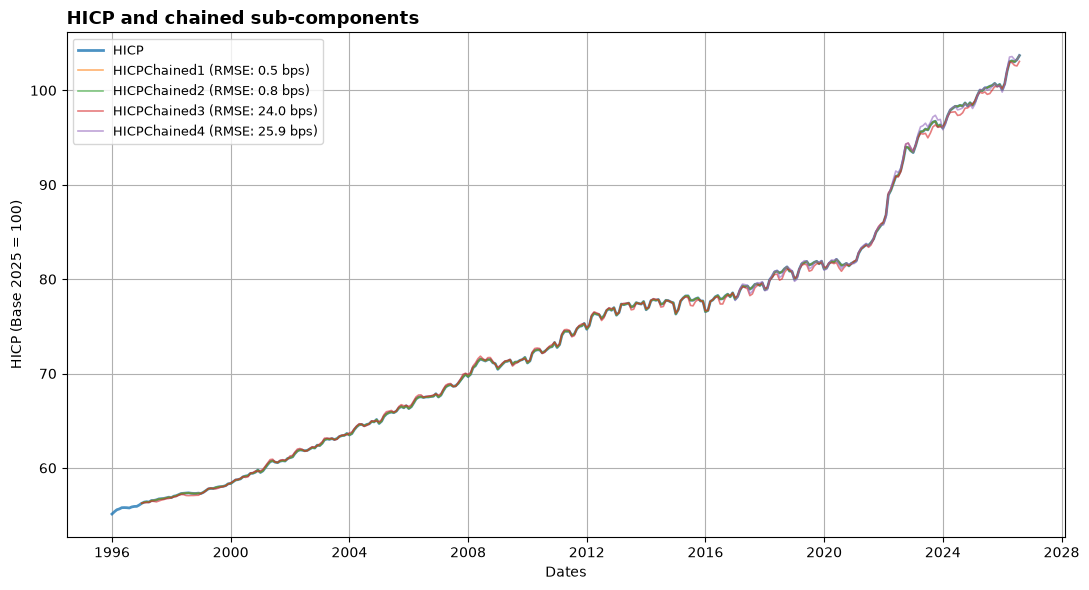

In [254]:
# RMSE in basis points
bpsRMSEs = RMSEs * 100

fig, ax = plt.subplots(figsize=(11, 6))
xAxis = ChainedResized.index

# HICP
ax.plot(
    xAxis,
    ChainedResized["INX"],
    lw=2,
    alpha=0.8,
    label="HICP"
)

# All chained series
for col in ChainedResized.columns[1:]:
    ax.plot(
        xAxis,
        ChainedResized[col],
        lw=1.2,
        alpha=0.6,
        label=f"{col} (RMSE: {bpsRMSEs[col]:.1f} bps)"
    )

ax.set_title(
    "HICP and chained sub-components",
    fontsize=13,
    fontweight="bold",
    loc="left"
)

ax.set_xlabel("Dates")
ax.set_ylabel("HICP (Base 2025 = 100)")
ax.legend(loc="best", fontsize=9)
ax.grid()
plt.tight_layout()
plt.show()

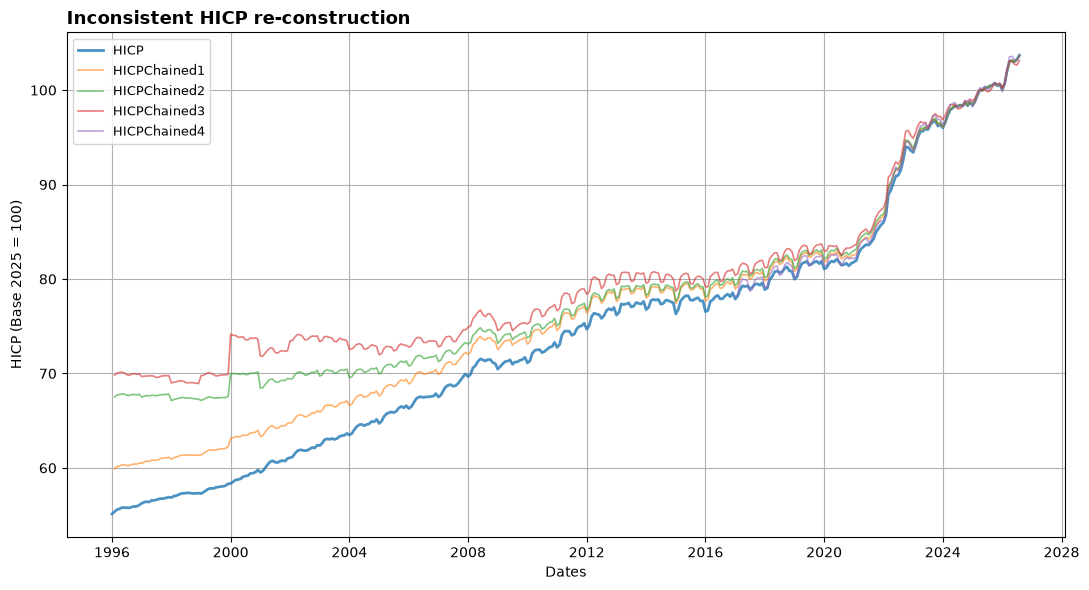

In [255]:
# Inconsistently computed
fig, ax = plt.subplots(figsize=(11, 6))
xAxis = IncResized.index

# HICP
ax.plot(
    xAxis,
    IncResized["INX"],
    lw=2,
    alpha=0.8,
    label="HICP"
)

# Inconsistent series
for col in IncResized.columns[1:]:
    ax.plot(
        xAxis,
        IncResized[col],
        lw=1.2,
        alpha=0.6,
        label=f"{col}"
    )

ax.set_title(
    "Inconsistent HICP re-construction",
    fontsize=13,
    fontweight="bold",
    loc="left"
)

ax.set_xlabel("Dates")
ax.set_ylabel("HICP (Base 2025 = 100)")
ax.legend(loc="best", fontsize=9)
ax.grid()
plt.tight_layout()
plt.show()

In [260]:
### Save output : unchained items, weights, HICP all items (index)
niv = "4"
dfUnchained = Niv0.merge(
    aggUnchained[f'HICPLvl{niv}'],
    how="left",
    right_index=True,
    left_index=True
)
dfUnchained.to_parquet(f"input/EAunchainedItemsLvl{niv}.parquet")

# Weights...
weightNormed[f'NormedWeightLvl{niv}'].to_parquet(f"input/EAnormedWeightsLvl{niv}.parquet")

**Careful :** Several dichotomies ; Ecoicop 1 does not account for the 13th component in the HICP - All Items (Personal care, social protection and miscellaneous goods and services) hence, the weights sum to 1015 (including the 13th component) instead of 1000. Moreover, the weights have been revised in 2015, see the differences in the HICP "fit" before and after the revision. 

In [259]:
# Change SeriesCode to titles in Weights
mapping = dFinal.set_index("ICP_ITEM")["TITLE"].to_dict()
weightNormed[f'NormedWeightLvl{niv}'] = weightNormed[f'NormedWeightLvl{niv}'].rename(columns=mapping)